In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/rishitgambhir17/loansense/data/accepted_2007_to_2018Q4.csv', low_memory=False, nrows=200000)
df = df.sample(n=50000, random_state=42).reset_index(drop=True)

print("Shape:", df.shape)
print("\n", df['loan_status'].value_counts())

Shape: (50000, 151)

 loan_status
Fully Paid            35370
Charged Off            8671
Current                5653
Late (31-120 days)      177
In Grace Period          88
Late (16-30 days)        40
Default                   1
Name: count, dtype: int64


In [6]:
# Keep only completed loans
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

print("Shape after filtering:", df.shape)
print("\nTarget distribution:")
print(df['target'].value_counts(normalize=True).round(3))

Shape after filtering: (44041, 152)

Target distribution:
target
0    0.803
1    0.197
Name: proportion, dtype: float64


In [7]:
keep_cols = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
    'pub_rec_bankruptcies', 'target'
]

df = df[keep_cols]
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

Shape: (44041, 22)

Missing values:
emp_length              2775
revol_util                22
loan_amnt                  0
delinq_2yrs                0
pub_rec_bankruptcies       0
mort_acc                   0
total_acc                  0
revol_bal                  0
pub_rec                    0
open_acc                   0
earliest_cr_line           0
dti                        0
term                       0
purpose                    0
verification_status        0
annual_inc                 0
home_ownership             0
sub_grade                  0
grade                      0
installment                0
int_rate                   0
target                     0
dtype: int64


In [8]:
# Check what emp_length looks like
print(df['emp_length'].value_counts())

emp_length
10+ years    14453
2 years       3905
< 1 year      3813
3 years       3492
1 year        2977
5 years       2639
4 years       2567
8 years       2240
9 years       1755
7 years       1748
6 years       1677
Name: count, dtype: int64


In [9]:
# Clean emp_length: convert to numeric
df['emp_length'] = df['emp_length'].replace({
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
})

# Fill missing emp_length with median
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())

# Fill missing revol_util with median
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())

# Verify no missing values left
print(df.isnull().sum().sum(), "total missing values")

0 total missing values


/var/folders/zg/51l5xkkn33nfw3lz1fq57pmr0000gn/T/ipykernel_90001/1937302392.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['emp_length'] = df['emp_length'].replace({


In [10]:
# Check which columns are still text
print(df.select_dtypes(include='object').columns.tolist())

['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'earliest_cr_line']


In [11]:
# term: extract number
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)

# earliest_cr_line: convert to credit history length in years
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
df['credit_history_years'] = (pd.Timestamp('2018-01-01') - df['earliest_cr_line']).dt.days / 365
df = df.drop('earliest_cr_line', axis=1)

# grade and sub_grade: drop sub_grade (redundant), encode grade as ordinal
df = df.drop('sub_grade', axis=1)
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade'] = df['grade'].map(grade_map)

# One-hot encode the rest: home_ownership, verification_status, purpose
df = pd.get_dummies(df, columns=['home_ownership', 'verification_status', 'purpose'], drop_first=True)

print("Shape:", df.shape)
print("\nAll numeric now:", df.select_dtypes(include='object').columns.tolist())

Shape: (44041, 35)

All numeric now: []


/var/folders/zg/51l5xkkn33nfw3lz1fq57pmr0000gn/T/ipykernel_90001/3934347036.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


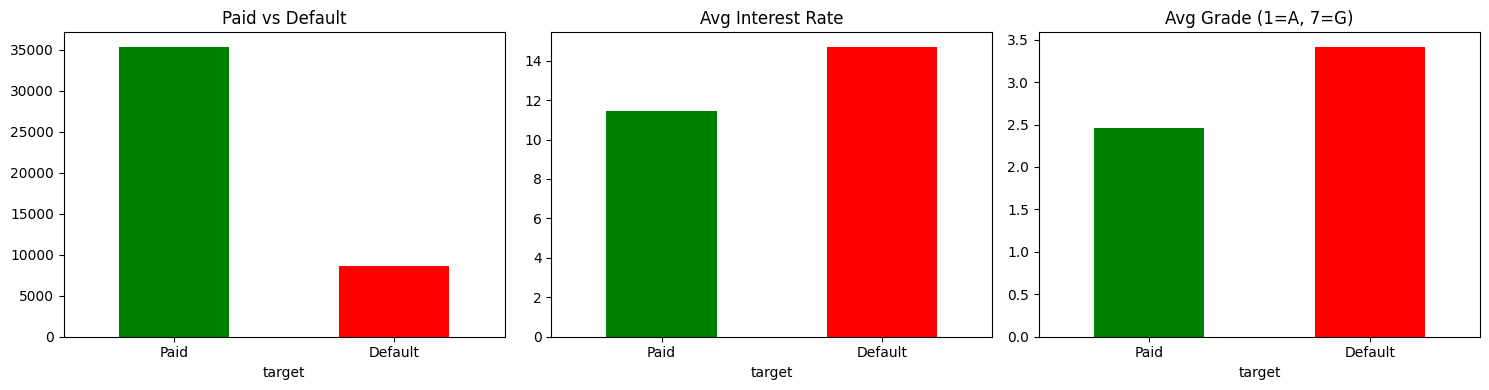

In [12]:
# Quick plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Target distribution
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Paid vs Default')
axes[0].set_xticklabels(['Paid', 'Default'], rotation=0)

# 2. Interest rate by class
df.groupby('target')['int_rate'].mean().plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Avg Interest Rate')
axes[1].set_xticklabels(['Paid', 'Default'], rotation=0)

# 3. Grade distribution by class
df.groupby('target')['grade'].mean().plot(kind='bar', ax=axes[2], color=['green', 'red'])
axes[2].set_title('Avg Grade (1=A, 7=G)')
axes[2].set_xticklabels(['Paid', 'Default'], rotation=0)

plt.tight_layout()
plt.show()

In [13]:
# Save cleaned data
df.to_csv('/Users/rishitgambhir17/loansense/data/cleaned_data.csv', index=False)
print("Saved! Shape:", df.shape)
print("Columns:", df.columns.tolist())

Saved! Shape: (44041, 35)
Columns: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'target', 'credit_history_years', 'home_ownership_MORTGAGE', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding']
